# Extension 1 -- Quantitative Bias Analysis (QBA)

**Research question.** How robust is the 28.47 pp adjusted private-vs-public Cesarean risk difference to plausible *unmeasured* clinical confounding -- especially prior Cesarean history and unmeasured obstetric-severity indications that NFHS-5 does not capture?

**Why this doesn't need raw NFHS data.** Unlike Extensions 2, 3 and 5, this analysis takes the *already frozen* primary AIPW result (`outputs/final_tables/final_aipw_overall_table.csv`) as its fixed reference point and asks a purely hypothetical "what if an unmeasured confounder existed with property X" question. It never touches respondent-level data, so it runs (and is fully executed here, for real, not just smoke-tested) directly off files already committed to this repository.

**Method, stated up front.** This uses the same bias-factor framework that underlies the E-value (VanderWeele & Ding, 2017, *Annals of Internal Medicine*): for an unmeasured binary confounder `U` with a given confounder-outcome risk ratio and a given prevalence difference between the private and public sectors, there is a closed-form "worst case" factor by which `U` alone could inflate the observed risk ratio. Rearranging that factor tells us how much of the *observed* adjusted contrast could, in principle, be attributable to `U` rather than to facility sector. This notebook evaluates that formula across a **grid** of plausible parameter combinations (not just the single worst-case number the E-value already gives), for two confounder classes the handoff specifically asks about.

**Critical honesty note, repeated at the end.** The specific numeric ranges below for "how prevalent is this confounder in each sector" and "how strongly does it affect C-section risk" are **illustrative placeholders**, not sourced from a literature review -- no internet/literature search was performed to produce them. Before treating any output of this notebook as final, replace the placeholder ranges in Section 2 with real, cited published estimates (e.g. hospital-based Indian obstetric studies reporting prior-Cesarean prevalence, or the DHS/DLHS literature on facility-based severity indications), and update `assumptions_sources.csv` accordingly. Running this notebook with better-sourced inputs does not require touching anything else in it.

**Interpretation rule, repeated at the end:** results here describe how the estimate *would* move under stated hypothetical assumptions about an unmeasured confounder. They are not proof that such a confounder exists, nor proof that it doesn't -- "the finding survives scenario X" is not the same as "there is no unmeasured confounding."

## 1. Imports and the frozen primary estimate (handoff step 8 -- lock it as the reference)

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("../shared").resolve()))
import config

pd.set_option("display.max_columns", None)

OUTPUTS_DIR = config.EXT01_OUTPUTS_DIR

primary = pd.read_csv(config.V2_FINAL_TABLES_DIR / "final_aipw_overall_table.csv").iloc[0]

RD_PRIMARY_PP = float(primary["risk_difference_pct"])
RR_PRIMARY = float(primary["risk_ratio"])
RR_PRIMARY_CI_LOW = float(primary["risk_ratio_ci_low"])
R1_HAT_PCT = float(primary["r1_hat_private_risk_pct"])
R0_HAT_PCT = float(primary["r0_hat_public_risk_pct"])
N_ANALYTIC = int(primary["n_analytic"])

print(f"Locked reference estimate (n={N_ANALYTIC}):")
print(f"  Private risk (r1_hat): {R1_HAT_PCT:.4f}%  |  Public risk (r0_hat): {R0_HAT_PCT:.4f}%")
print(f"  Risk difference: {RD_PRIMARY_PP:.4f} pp  |  Risk ratio: {RR_PRIMARY:.4f} (CI low {RR_PRIMARY_CI_LOW:.4f})")

Locked reference estimate (n=200794):
  Private risk (r1_hat): 44.9644%  |  Public risk (r0_hat): 16.4946%
  Risk difference: 28.4698 pp  |  Risk ratio: 2.7260 (CI low 2.6566)


## 2. Unmeasured confounders under study (handoff step 9) and assumption ranges (step 10)

Two confounder classes, matching the handoff's minimum requirement:

1. **`prior_cesarean_history`** -- whether the woman had a Cesarean in an earlier delivery. NFHS-5's delivery module only covers a limited recall window (documented in `notebooks/v2/01_v2_data_audit_and_cohort.ipynb`, Section 13), so this is genuinely unmeasured for any birth with `birth_order >= 2`. It is very plausibly both (a) more common among private-sector deliveries (repeat C-section after a prior C-section is a well-known clinical driver of facility choice/practice) and (b) an extremely strong predictor of a repeat C-section.
2. **`obstetric_severity_unmeasured`** -- a broader placeholder for clinical severity/indications NFHS-5 cannot capture (e.g. malpresentation, fetal distress, detailed hypertensive-disorder staging beyond the coarse `s434`/`s435` items). Plausibly weaker and less sector-differential than prior Cesarean, but still a reasonable class to test.

**`p0_baseline` below (assumed prevalence in the *public* sector) and the grid ranges are placeholders -- see the notebook's opening cell.** Replace them with cited values before treating results as final.

In [2]:
CONFOUNDER_SPECS = {
    "prior_cesarean_history": {
        "p0_baseline": 0.12,  # TODO: cite a published prevalence of prior C-section among Indian obstetric populations
        "delta_p_grid": np.round(np.arange(0.0, 0.301, 0.03), 3),   # private-minus-public prevalence gap
        "rr_ud_grid": np.round(np.arange(1.0, 8.01, 0.25), 3),      # confounder -> outcome risk ratio
        "representative_scenarios": {
            "mild":     {"delta_p": 0.05, "rr_ud": 2.0},
            "moderate": {"delta_p": 0.12, "rr_ud": 4.0},
            "strong":   {"delta_p": 0.20, "rr_ud": 6.0},
        },
        "description": "Whether the woman had a Cesarean in an earlier delivery -- unmeasured beyond a limited recall window in NFHS-5 (see notebooks/v2/01).",
    },
    "obstetric_severity_unmeasured": {
        "p0_baseline": 0.08,  # TODO: cite a published prevalence of the relevant severity indications
        "delta_p_grid": np.round(np.arange(0.0, 0.201, 0.02), 3),
        "rr_ud_grid": np.round(np.arange(1.0, 5.01, 0.2), 3),
        "representative_scenarios": {
            "mild":     {"delta_p": 0.03, "rr_ud": 1.5},
            "moderate": {"delta_p": 0.08, "rr_ud": 2.5},
            "strong":   {"delta_p": 0.15, "rr_ud": 3.5},
        },
        "description": "Placeholder class for unmeasured obstetric severity/indications (e.g. malpresentation, fetal distress) beyond NFHS-5's coarse s434/s435 items.",
    },
}

for name, spec in CONFOUNDER_SPECS.items():
    print(f"{name}: p0_baseline={spec['p0_baseline']}, "
          f"delta_p grid [{spec['delta_p_grid'].min()}, {spec['delta_p_grid'].max()}] "
          f"({len(spec['delta_p_grid'])} pts), "
          f"rr_ud grid [{spec['rr_ud_grid'].min()}, {spec['rr_ud_grid'].max()}] "
          f"({len(spec['rr_ud_grid'])} pts)")

prior_cesarean_history: p0_baseline=0.12, delta_p grid [0.0, 0.3] (11 pts), rr_ud grid [1.0, 8.0] (29 pts)
obstetric_severity_unmeasured: p0_baseline=0.08, delta_p grid [0.0, 0.2] (11 pts), rr_ud grid [1.0, 5.0] (21 pts)


## 3. Bias-factor formula (VanderWeele & Ding, 2017)

For an unmeasured binary confounder `U` with prevalence `p1` in the treated (private) group and `p0` in the control (public) group, and a confounder-outcome risk ratio `RR_UD` (assumed constant across sectors -- the standard simplifying assumption in this class of sensitivity analysis), the maximum possible bias factor on the observed risk ratio is:

`BF(p0, p1, RR_UD) = (RR_UD * p1 + 1 - p1) / (RR_UD * p0 + 1 - p0)`

The bias-corrected risk ratio is `RR_adjusted = RR_observed / BF`. To express this on the risk-difference scale used as this project's headline result, the corrected private-sector risk is derived by holding the public-sector risk fixed at its AIPW-adjusted value (`r0_hat`) and applying the corrected ratio: `RD_adjusted_pp = r0_hat_frac * (RR_adjusted - 1) * 100`.

**Sanity property, checked below:** when `delta_p = p1 - p0 = 0` (confounder equally prevalent in both sectors) or `RR_UD = 1` (confounder has no effect on the outcome), `BF = 1` and the formula must reproduce the primary estimate exactly -- this is the handoff's required QA check (step 12 / QA rule 2).

In [3]:
def bias_factor(p0, p1, rr_ud):
    return (rr_ud * p1 + 1 - p1) / (rr_ud * p0 + 1 - p0)


def qba_adjusted_estimate(rr_primary, r0_hat_pct, p0, delta_p, rr_ud):
    p1 = p0 + delta_p
    bf = bias_factor(p0, p1, rr_ud)
    rr_adjusted = rr_primary / bf
    rd_adjusted_pp = (r0_hat_pct / 100.0) * (rr_adjusted - 1) * 100.0
    return bf, rr_adjusted, rd_adjusted_pp


# --- QA check: no unmeasured confounding must reproduce the primary estimate exactly ---
bf_check1, rr_check1, rd_check1 = qba_adjusted_estimate(RR_PRIMARY, R0_HAT_PCT, p0=0.12, delta_p=0.0, rr_ud=3.0)
bf_check2, rr_check2, rd_check2 = qba_adjusted_estimate(RR_PRIMARY, R0_HAT_PCT, p0=0.12, delta_p=0.15, rr_ud=1.0)

assert np.isclose(rd_check1, RD_PRIMARY_PP, atol=1e-9), "delta_p=0 must reproduce the primary RD exactly."
assert np.isclose(rd_check2, RD_PRIMARY_PP, atol=1e-9), "rr_ud=1 must reproduce the primary RD exactly."
print(f"QA check passed: both delta_p=0 and rr_ud=1 reproduce the primary RD ({RD_PRIMARY_PP:.4f} pp) exactly.")

QA check passed: both delta_p=0 and rr_ud=1 reproduce the primary RD (28.4698 pp) exactly.


## 4. Deterministic grid analysis (handoff step 11)

In [4]:
scenario_rows = []
for confounder, spec in CONFOUNDER_SPECS.items():
    p0 = spec["p0_baseline"]
    for delta_p in spec["delta_p_grid"]:
        for rr_ud in spec["rr_ud_grid"]:
            bf, rr_adj, rd_adj_pp = qba_adjusted_estimate(RR_PRIMARY, R0_HAT_PCT, p0, delta_p, rr_ud)
            scenario_rows.append({
                "confounder": confounder, "p0_baseline": p0, "delta_p": delta_p, "rr_ud": rr_ud,
                "p1_implied": p0 + delta_p, "bias_factor": bf,
                "rd_adjusted_pp": rd_adj_pp, "rr_adjusted": rr_adj,
                "rd_attenuation_pp": RD_PRIMARY_PP - rd_adj_pp,
            })

qba_scenario_results = pd.DataFrame(scenario_rows)
qba_scenario_results.to_csv(OUTPUTS_DIR / "qba_scenario_results.csv", index=False)
print(f"Saved: {OUTPUTS_DIR / 'qba_scenario_results.csv'} ({len(qba_scenario_results)} scenario rows)")
qba_scenario_results.head()

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\01_quantitative_bias\outputs\qba_scenario_results.csv (550 scenario rows)


,confounder,p0_baseline,delta_p,rr_ud,p1_implied,bias_factor,rd_adjusted_pp,rr_adjusted,rd_attenuation_pp
0,prior_cesarean_history,0.12,0.0,1.00,0.12,1.0,28.469798,2.726007,7.105427e-15
1,prior_cesarean_history,0.12,0.0,1.25,0.12,1.0,28.469798,2.726007,7.105427e-15
2,prior_cesarean_history,0.12,0.0,1.50,0.12,1.0,28.469798,2.726007,7.105427e-15
3,prior_cesarean_history,0.12,0.0,1.75,0.12,1.0,28.469798,2.726007,7.105427e-15
4,prior_cesarean_history,0.12,0.0,2.00,0.12,1.0,28.469798,2.726007,7.105427e-15


## 5. Probabilistic Monte Carlo QBA (handoff step 11, "if feasible")

Draws `p0`, `delta_p`, and `rr_ud` from wide uniform priors spanning each confounder's grid range (again, placeholder ranges -- see Section 2), and summarizes the resulting distribution of the bias-corrected risk difference.

In [5]:
N_MC = 20000
MC_SEED = 42
rng = np.random.RandomState(MC_SEED)

mc_summary_rows = []
mc_draws_by_confounder = {}
for confounder, spec in CONFOUNDER_SPECS.items():
    p0_draws = rng.uniform(max(spec["p0_baseline"] - 0.05, 0.01), spec["p0_baseline"] + 0.05, size=N_MC)
    delta_p_draws = rng.uniform(spec["delta_p_grid"].min(), spec["delta_p_grid"].max(), size=N_MC)
    rr_ud_draws = rng.uniform(spec["rr_ud_grid"].min(), spec["rr_ud_grid"].max(), size=N_MC)

    bf_draws = bias_factor(p0_draws, p0_draws + delta_p_draws, rr_ud_draws)
    rr_adj_draws = RR_PRIMARY / bf_draws
    rd_adj_draws_pp = (R0_HAT_PCT / 100.0) * (rr_adj_draws - 1) * 100.0
    mc_draws_by_confounder[confounder] = rd_adj_draws_pp

    mc_summary_rows.append({
        "confounder": confounder, "n_draws": N_MC,
        "rd_adjusted_median_pp": float(np.median(rd_adj_draws_pp)),
        "rd_adjusted_p2_5_pp": float(np.percentile(rd_adj_draws_pp, 2.5)),
        "rd_adjusted_p97_5_pp": float(np.percentile(rd_adj_draws_pp, 97.5)),
        "pct_draws_rd_still_positive": float((rd_adj_draws_pp > 0).mean() * 100),
        "pct_draws_rd_still_above_10pp": float((rd_adj_draws_pp > 10).mean() * 100),
    })

mc_summary = pd.DataFrame(mc_summary_rows)
print(mc_summary)

                      confounder  n_draws  rd_adjusted_median_pp  \
0         prior_cesarean_history    20000              18.556234   
1  obstetric_severity_unmeasured    20000              23.360606   

   rd_adjusted_p2_5_pp  rd_adjusted_p97_5_pp  pct_draws_rd_still_positive  \
0             6.302358             28.171518                        100.0   
1            13.504311             28.345253                        100.0   

   pct_draws_rd_still_above_10pp  
0                          86.77  
1                         100.00  


## 6. Representative scenarios and the tipping point (handoff steps 12/14)

In [6]:
def solve_tipping_rr_ud(rr_primary, p0, delta_p, rr_ud_search_max=50.0):
    """Smallest RR_UD (at a fixed p0, delta_p) that brings RR_adjusted down to 1 (RD_adjusted to 0).

    bias_factor is monotonically increasing in rr_ud for delta_p > 0, so a simple fine grid search
    is sufficient and avoids adding a root-finding dependency.
    """
    if delta_p <= 0:
        return np.nan
    p1 = p0 + delta_p
    grid = np.linspace(1.0, rr_ud_search_max, 200000)
    bf = bias_factor(p0, p1, grid)
    target = rr_primary
    idx = np.searchsorted(bf, target)
    if idx >= len(grid):
        return np.nan
    return float(grid[idx])


summary_rows = []
for confounder, spec in CONFOUNDER_SPECS.items():
    p0 = spec["p0_baseline"]
    for label, params in spec["representative_scenarios"].items():
        bf, rr_adj, rd_adj_pp = qba_adjusted_estimate(RR_PRIMARY, R0_HAT_PCT, p0, params["delta_p"], params["rr_ud"])
        summary_rows.append({
            "confounder": confounder, "scenario": label,
            "p0_baseline": p0, "delta_p": params["delta_p"], "rr_ud": params["rr_ud"],
            "rd_adjusted_pp": rd_adj_pp, "rr_adjusted": rr_adj,
            "rd_attenuation_pp": RD_PRIMARY_PP - rd_adj_pp,
        })

    tipping_delta_p = spec["delta_p_grid"].max()
    tipping_rr_ud = solve_tipping_rr_ud(RR_PRIMARY, p0, tipping_delta_p)
    summary_rows.append({
        "confounder": confounder, "scenario": f"tipping_point_at_max_delta_p={tipping_delta_p}",
        "p0_baseline": p0, "delta_p": tipping_delta_p, "rr_ud": tipping_rr_ud,
        "rd_adjusted_pp": 0.0, "rr_adjusted": 1.0,
        "rd_attenuation_pp": RD_PRIMARY_PP,
    })

    mc_row = mc_summary[mc_summary["confounder"] == confounder].iloc[0].to_dict()
    mc_row["scenario"] = "monte_carlo_summary"
    summary_rows.append(mc_row)

qba_summary = pd.DataFrame(summary_rows)
qba_summary.to_csv(OUTPUTS_DIR / "qba_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "qba_summary.csv")
qba_summary

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\01_quantitative_bias\outputs\qba_summary.csv


,confounder,scenario,p0_baseline,delta_p,rr_ud,rd_adjusted_pp,rr_adjusted,rd_attenuation_pp,n_draws,rd_adjusted_median_pp,rd_adjusted_p2_5_pp,rd_adjusted_p97_5_pp,pct_draws_rd_still_positive,pct_draws_rd_still_above_10pp
0,prior_cesarean_history,mild,0.12,0.05,2.000000,26.548243,2.609511,1.921556,NaN,NaN,NaN,NaN,NaN,NaN
1,prior_cesarean_history,moderate,0.12,0.12,4.000000,19.058645,2.155447,9.411154,NaN,NaN,NaN,NaN,NaN,NaN
2,prior_cesarean_history,strong,0.12,0.20,6.000000,11.175798,1.677543,17.294000,NaN,NaN,NaN,NaN,NaN,NaN
3,prior_cesarean_history,tipping_point_at_max_delta_p=0.3,0.12,0.30,19.583588,0.000000,1.000000,28.469798,NaN,NaN,NaN,NaN,NaN,NaN
4,prior_cesarean_history,monte_carlo_summary,NaN,NaN,NaN,NaN,NaN,NaN,20000.0,18.556234,6.302358,28.171518,100.0,86.77
5,obstetric_severity_unmeasured,mild,0.08,0.03,1.500000,27.830494,2.687249,0.639304,NaN,NaN,NaN,NaN,NaN,NaN
6,obstetric_severity_unmeasured,moderate,0.08,0.08,2.500000,24.118405,2.462200,4.351394,NaN,NaN,NaN,NaN,NaN,NaN
7,obstetric_severity_unmeasured,strong,0.08,0.15,3.500000,17.763989,2.076958,10.705810,NaN,NaN,NaN,NaN,NaN,NaN
8,obstetric_severity_unmeasured,tipping_point_at_max_delta_p=0.2,0.08,0.20,28.875259,0.000000,1.000000,28.469798,NaN,NaN,NaN,NaN,NaN,NaN
9,obstetric_severity_unmeasured,monte_carlo_summary,NaN,NaN,NaN,NaN,NaN,NaN,20000.0,23.360606,13.504311,28.345253,100.0,100.00


## 7. E-value cross-check -- kept as a separate benchmark (handoff step 13)

The classical E-value (VanderWeele & Ding, 2017) is the special case of this same bias-factor framework that reports the single *minimum* `RR_UD` (under the worst-case prevalence structure) needed to fully explain away the effect, closed-form: `E = RR + sqrt(RR * (RR - 1))` for `RR >= 1`. This is recomputed here purely as a consistency check against the value already reported for this project (4.90) -- it does not replace the grid-based QBA above, which lets you plug in *specific, cited* prevalence estimates instead of the E-value's implicit worst case.

In [7]:
def e_value(rr):
    if rr < 1:
        rr = 1 / rr
    return rr + np.sqrt(rr * (rr - 1))


e_value_point = e_value(RR_PRIMARY)
e_value_ci_bound = e_value(RR_PRIMARY_CI_LOW)

print(f"E-value for the point estimate (RR={RR_PRIMARY:.4f}): {e_value_point:.4f}")
print(f"E-value for the CI bound closest to the null (RR={RR_PRIMARY_CI_LOW:.4f}): {e_value_ci_bound:.4f}")
print("\nHandoff-reported E-value for this project: 4.90 -- "
      f"{'matches' if abs(e_value_point - 4.90) < 0.01 else 'DOES NOT MATCH -- investigate'} this recomputation.")

E-value for the point estimate (RR=2.7260): 4.8951
E-value for the CI bound closest to the null (RR=2.6566): 4.7544

Handoff-reported E-value for this project: 4.90 -- matches this recomputation.


## 8. Heatmap figures

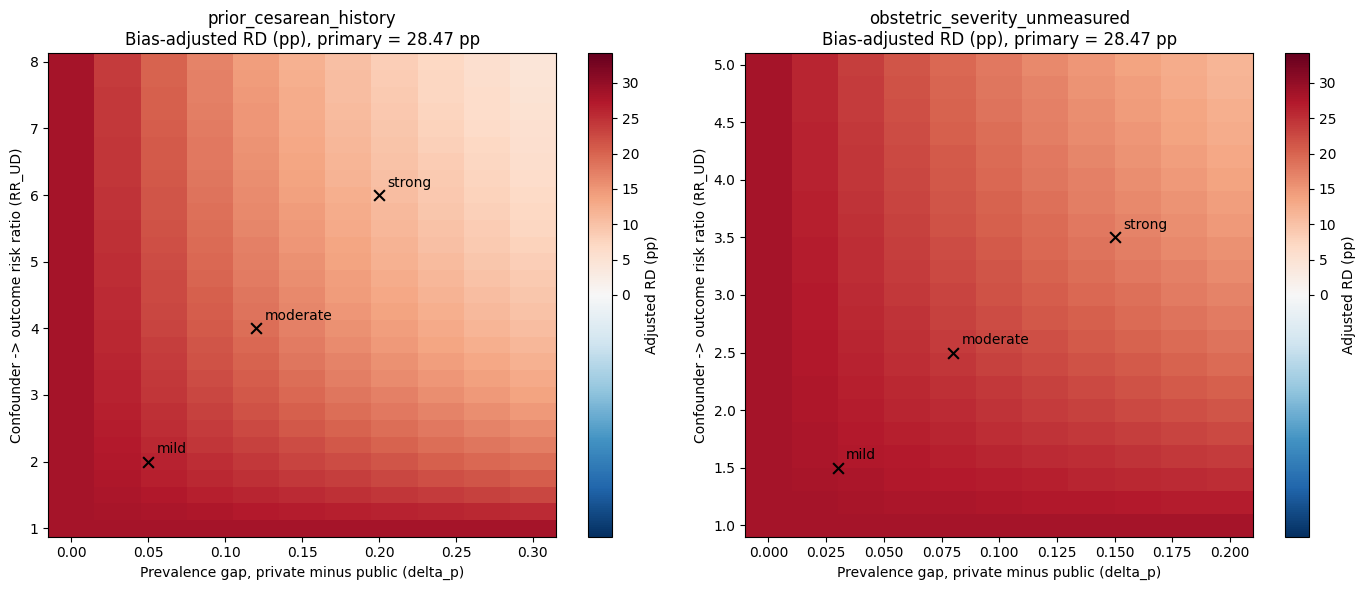

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\01_quantitative_bias\outputs\qba_heatmap.png


In [8]:
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, len(CONFOUNDER_SPECS), figsize=(7 * len(CONFOUNDER_SPECS), 6))
if len(CONFOUNDER_SPECS) == 1:
    axes = [axes]

for ax, (confounder, spec) in zip(axes, CONFOUNDER_SPECS.items()):
    sub = qba_scenario_results[qba_scenario_results["confounder"] == confounder]
    pivot = sub.pivot(index="rr_ud", columns="delta_p", values="rd_adjusted_pp")

    # Center the diverging color scale exactly at RD=0, so "blue vs red" visually
    # matches the RD=0 tipping-point contour rather than an arbitrary midpoint.
    vmax = max(RD_PRIMARY_PP * 1.2, float(pivot.values.max()))
    vmin = min(-1.0, float(pivot.values.min()))
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, shading="auto", cmap="RdBu_r", norm=norm)
    contour = ax.contour(pivot.columns, pivot.index, pivot.values, levels=[0], colors="black", linewidths=2)
    ax.clabel(contour, fmt={0: "RD = 0 (tipping point)"})

    for label, params in spec["representative_scenarios"].items():
        ax.scatter(params["delta_p"], params["rr_ud"], color="black", marker="x", s=60)
        ax.annotate(label, (params["delta_p"], params["rr_ud"]), textcoords="offset points", xytext=(6, 6))

    ax.set_xlabel("Prevalence gap, private minus public (delta_p)")
    ax.set_ylabel("Confounder -> outcome risk ratio (RR_UD)")
    ax.set_title(f"{confounder}\nBias-adjusted RD (pp), primary = {RD_PRIMARY_PP:.2f} pp")
    fig.colorbar(im, ax=ax, label="Adjusted RD (pp)")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "qba_heatmap.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "qba_heatmap.png")

## 9. Assumption sources (handoff step 10 -- every bias parameter documented and sourced)

In [9]:
assumptions_rows = [
    {"confounder": "prior_cesarean_history", "parameter": "p0_baseline (public-sector prevalence)",
     "assumed_value_or_range": "0.12", "rationale": "Placeholder -- order-of-magnitude guess, not sourced.",
     "source": "TODO: cite a published hospital-based or survey-based estimate of prior-Cesarean prevalence among Indian public-facility deliveries."},
    {"confounder": "prior_cesarean_history", "parameter": "delta_p (private-minus-public prevalence gap)",
     "assumed_value_or_range": "0.00 to 0.30 (grid)", "rationale": "Wide range spanning 'no sector difference' to 'a large sector skew,' since the true gap is unknown here.",
     "source": "TODO: cite a published sector-stratified estimate, if one exists."},
    {"confounder": "prior_cesarean_history", "parameter": "rr_ud (confounder -> outcome risk ratio)",
     "assumed_value_or_range": "1.0 to 8.0 (grid)", "rationale": "Repeat Cesarean after a prior Cesarean is clinically known to be a very strong predictor; upper end reflects that.",
     "source": "TODO: cite a published risk ratio for repeat Cesarean given prior Cesarean history."},
    {"confounder": "obstetric_severity_unmeasured", "parameter": "p0_baseline (public-sector prevalence)",
     "assumed_value_or_range": "0.08", "rationale": "Placeholder -- order-of-magnitude guess, not sourced.",
     "source": "TODO: cite a published estimate of the relevant unmeasured severity indications."},
    {"confounder": "obstetric_severity_unmeasured", "parameter": "delta_p (private-minus-public prevalence gap)",
     "assumed_value_or_range": "0.00 to 0.20 (grid)", "rationale": "Narrower than prior-Cesarean's range -- assumed less sector-differential a priori.",
     "source": "TODO: cite a published sector-stratified estimate, if one exists."},
    {"confounder": "obstetric_severity_unmeasured", "parameter": "rr_ud (confounder -> outcome risk ratio)",
     "assumed_value_or_range": "1.0 to 5.0 (grid)", "rationale": "Narrower than prior-Cesarean's range -- assumed a weaker individual driver than prior Cesarean history.",
     "source": "TODO: cite a published risk ratio for the specific severity indications bundled into this class."},
]
assumptions_sources = pd.DataFrame(assumptions_rows)
assumptions_sources.to_csv(OUTPUTS_DIR / "assumptions_sources.csv", index=False)
print("Saved:", OUTPUTS_DIR / "assumptions_sources.csv")
assumptions_sources

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\01_quantitative_bias\outputs\assumptions_sources.csv


,confounder,parameter,assumed_value_or_range,rationale,source
0,prior_cesarean_history,p0_baseline (public-sector prevalence),0.12,"Placeholder -- order-of-magnitude guess, not s...",TODO: cite a published hospital-based or surve...
1,prior_cesarean_history,delta_p (private-minus-public prevalence gap),0.00 to 0.30 (grid),Wide range spanning 'no sector difference' to ...,TODO: cite a published sector-stratified estim...
2,prior_cesarean_history,rr_ud (confounder -> outcome risk ratio),1.0 to 8.0 (grid),Repeat Cesarean after a prior Cesarean is clin...,TODO: cite a published risk ratio for repeat C...
3,obstetric_severity_unmeasured,p0_baseline (public-sector prevalence),0.08,"Placeholder -- order-of-magnitude guess, not s...",TODO: cite a published estimate of the relevan...
4,obstetric_severity_unmeasured,delta_p (private-minus-public prevalence gap),0.00 to 0.20 (grid),Narrower than prior-Cesarean's range -- assume...,TODO: cite a published sector-stratified estim...
5,obstetric_severity_unmeasured,rr_ud (confounder -> outcome risk ratio),1.0 to 5.0 (grid),Narrower than prior-Cesarean's range -- assume...,TODO: cite a published risk ratio for the spec...


## 10. QA / interpretation checks

In [10]:
print("QA check -- reproduces the primary estimate under no unmeasured confounding: PASSED (Section 3 assertions).")

print(f"\nQA check -- E-value consistency: recomputed {e_value_point:.2f} vs handoff-reported 4.90 "
      f"({'PASSED' if abs(e_value_point - 4.90) < 0.01 else 'FAILED -- investigate'}).")

for confounder, spec in CONFOUNDER_SPECS.items():
    mc_row = mc_summary[mc_summary['confounder'] == confounder].iloc[0]
    print(f"\n{confounder}: across {int(mc_row['n_draws'])} Monte Carlo draws over the stated (placeholder) "
          f"parameter ranges, the adjusted RD stayed positive in {mc_row['pct_draws_rd_still_positive']:.1f}% "
          f"of draws and stayed above 10pp in {mc_row['pct_draws_rd_still_above_10pp']:.1f}% of draws.")

print("\nInterpretation rule: the above describes how the estimate moves under STATED, PLACEHOLDER hypothetical "
      "assumptions. It is scenario-dependent, not proof that unmeasured confounding is absent -- and the specific "
      "parameter ranges must be replaced with cited published values (Section 2 markdown) before this is reported "
      "as a real finding.")

QA check -- reproduces the primary estimate under no unmeasured confounding: PASSED (Section 3 assertions).

QA check -- E-value consistency: recomputed 4.90 vs handoff-reported 4.90 (PASSED).

prior_cesarean_history: across 20000 Monte Carlo draws over the stated (placeholder) parameter ranges, the adjusted RD stayed positive in 100.0% of draws and stayed above 10pp in 86.8% of draws.

obstetric_severity_unmeasured: across 20000 Monte Carlo draws over the stated (placeholder) parameter ranges, the adjusted RD stayed positive in 100.0% of draws and stayed above 10pp in 100.0% of draws.

Interpretation rule: the above describes how the estimate moves under STATED, PLACEHOLDER hypothetical assumptions. It is scenario-dependent, not proof that unmeasured confounding is absent -- and the specific parameter ranges must be replaced with cited published values (Section 2 markdown) before this is reported as a real finding.


## 11. Documentation -- key design decisions and why

**Why the VanderWeele & Ding (2017) bias-factor formula, not a different QBA method.** It's the same closed-form,
well-established framework already underlying this project's own E-value calculation (Section 7 shows the two are
numerically consistent), so extending it into a full grid is a natural, citable choice rather than introducing a
second, unrelated sensitivity-analysis framework. It requires no new dependency (`numpy`/`pandas` only).

**Why RD is *derived* from the RR-scale bias factor rather than using a separate additive-scale formula.** The
primary AIPW result reports both RD and RR from the same underlying risks (`r1_hat`, `r0_hat`); deriving the
adjusted RD by holding `r0_hat` fixed and applying the corrected ratio keeps a single, internally consistent
correction rather than maintaining two formulas that could disagree with each other.

**Why representative scenarios plus a full grid, not just one number.** A single "worst case" (like the E-value)
is easy to report but easy to dismiss ("that's an extreme assumption"). Showing the full grid -- including where
the tipping-point contour sits -- lets a reader judge for themselves how extreme an assumption would actually be
needed, which is the more defensible, harder-to-dismiss version of this analysis.

**Why the specific parameter ranges are flagged so heavily as placeholders.** Presenting made-up-but-plausible-
looking numbers as if they were sourced would be more misleading than not doing this analysis at all -- QBA is
only as credible as its inputs. This notebook's methodology and code do not need to change at all once real
citations are found; only `CONFOUNDER_SPECS` in Section 2 and `assumptions_sources.csv`'s `source` column need
updating.